# Cluster Profiling and Interpretation

## Overview

Fitting a clustering algorithm is the beginning, not the end. The scientific value comes from understanding what the clusters represent — which features define them, how they differ from each other, and whether the groupings are meaningful in the domain context.

**Profiling workflow:**
1. Compute per-cluster summary statistics for all features
2. Test which features differ significantly across clusters (ANOVA / Kruskal-Wallis)
3. Visualise cluster separation with box plots, heatmaps, and radar charts
4. Name clusters based on their dominant characteristics
5. Validate against external variables not used in clustering

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rng = np.random.default_rng(42)
centers = {
    "highland_ref": (320, 7.8, 1.2, 0.8, 28),
    "lowland_imp":  (80,  6.6, 6.5, 3.2, 12),
    "midland_mod":  (160, 7.1, 3.2, 1.8, 20),
    "restored":     (200, 7.4, 2.1, 1.2, 25),
}
feat_names = ["elevation","ph","nitrate","phosphorus","richness"]
X_list = []
for name, center in centers.items():
    n = rng.integers(55, 75)
    X_list.append(np.column_stack([
        rng.normal(center[i], [40,0.2,1.0,0.5,3][i], n)
        for i in range(5)
    ]))
X = np.vstack(X_list)
df = pd.DataFrame(X, columns=feat_names)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
km = KMeans(n_clusters=4, n_init=20, random_state=42)
df["cluster"] = km.fit_predict(X_sc)
print(df.groupby("cluster")[feat_names].mean().round(2))

         elevation    ph  nitrate  phosphorus  richness
cluster                                                
0           322.88  7.77     1.16        0.81     28.12
1            80.99  6.60     6.48        3.12     11.58
2           160.47  7.13     3.15        1.73     20.49
3           204.77  7.45     1.85        1.08     25.11


---
## Per-Cluster Summary Statistics

In [2]:
summary = df.groupby("cluster")[feat_names].agg(["mean","median","std"])
print("Cluster profiles (mean / median / SD):")
print(summary.round(2))
cluster_sizes = df["cluster"].value_counts().sort_index()
print(f"\nCluster sizes: {cluster_sizes.to_dict()}")

Cluster profiles (mean / median / SD):
        elevation                   ph              nitrate               \
             mean  median    std  mean median   std    mean median   std   
cluster                                                                    
0          322.88  324.67  29.09  7.77   7.76  0.15    1.16   1.04  1.05   
1           80.99   82.88  41.58  6.60   6.64  0.20    6.48   6.47  1.04   
2          160.47  158.02  40.47  7.13   7.16  0.20    3.15   3.18  0.92   
3          204.77  210.38  35.90  7.45   7.43  0.18    1.85   1.90  1.04   

        phosphorus              richness               
              mean median   std     mean median   std  
cluster                                                
0             0.81   0.80  0.45    28.12  27.71  3.36  
1             3.12   3.11  0.55    11.58  11.80  3.02  
2             1.73   1.74  0.47    20.49  20.51  3.06  
3             1.08   1.01  0.48    25.11  25.60  3.22  

Cluster sizes: {0: 55, 1: 71, 2: 78

---
## Which Features Discriminate Clusters?

In [3]:
print("Kruskal-Wallis test per feature:")
for feat in feat_names:
    groups = [df.loc[df["cluster"]==k, feat].values for k in sorted(df["cluster"].unique())]
    H, p = stats.kruskal(*groups)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
    print(f"  {feat:12s}: H={H:.1f}, p={p:.4f} {sig}")
print("\n*** p<0.001  ** p<0.01  * p<0.05")

Kruskal-Wallis test per feature:
  elevation   : H=215.6, p=0.0000 ***
  ph          : H=226.8, p=0.0000 ***
  nitrate     : H=199.5, p=0.0000 ***
  phosphorus  : H=196.5, p=0.0000 ***
  richness    : H=209.7, p=0.0000 ***

*** p<0.001  ** p<0.01  * p<0.05


---
## Box Plots by Cluster

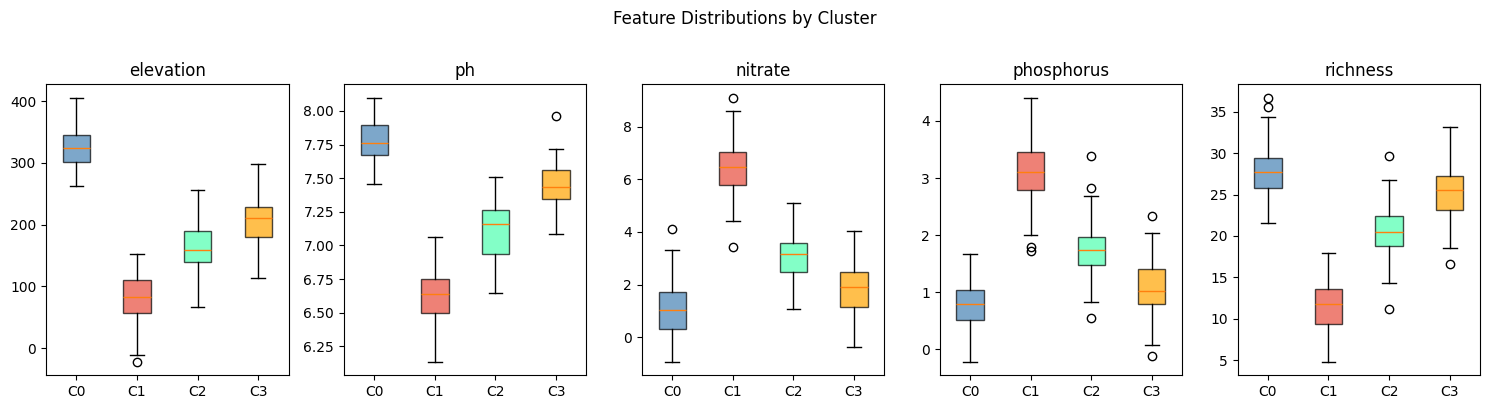

In [4]:
fig, axes = plt.subplots(1, len(feat_names), figsize=(15,4))
colors = ["steelblue","#e74c3c","#4fffb0","orange"]
for ax, feat in zip(axes, feat_names):
    groups = [df.loc[df["cluster"]==k, feat].values
              for k in sorted(df["cluster"].unique())]
    bp = ax.boxplot(groups, patch_artist=True, notch=False)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(feat); ax.set_xticklabels([f"C{k}" for k in sorted(df["cluster"].unique())])
plt.suptitle("Feature Distributions by Cluster", y=1.01)
plt.tight_layout(); plt.show()

---
## Heatmap of Standardised Cluster Centroids

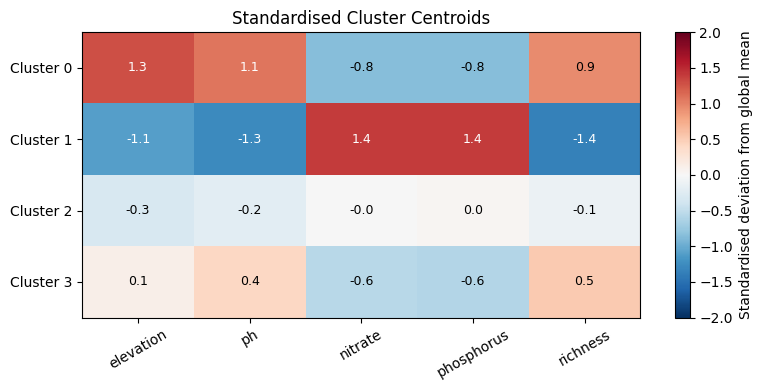


Cluster interpretation:
  Cluster 0: most distinctive feature = elevation (high)
  Cluster 1: most distinctive feature = nitrate (high)
  Cluster 2: most distinctive feature = elevation (low)
  Cluster 3: most distinctive feature = phosphorus (low)


In [5]:
# Standardised centroids: how many SDs each cluster is from the global mean
centroid_df = df.groupby("cluster")[feat_names].mean()
centroid_std = (centroid_df - centroid_df.mean()) / centroid_df.std()
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(centroid_std.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(feat_names))); ax.set_xticklabels(feat_names, rotation=30)
ax.set_yticks(range(4)); ax.set_yticklabels([f"Cluster {k}" for k in centroid_df.index])
plt.colorbar(im, ax=ax, label="Standardised deviation from global mean")
for i in range(4):
    for j in range(len(feat_names)):
        ax.text(j, i, f"{centroid_std.values[i,j]:.1f}", ha="center", va="center",
                fontsize=9, color="white" if abs(centroid_std.values[i,j])>1 else "black")
ax.set_title("Standardised Cluster Centroids")
plt.tight_layout(); plt.show()
print("\nCluster interpretation:")
for k in centroid_std.index:
    dominant = centroid_std.loc[k].abs().idxmax()
    direction = "high" if centroid_std.loc[k, dominant] > 0 else "low"
    print(f"  Cluster {k}: most distinctive feature = {dominant} ({direction})")

---

## Common Pitfalls

**1. Reporting only cluster means without spread or tests**  
Two clusters can have the same mean for a feature but very different variance. Always report standard deviations alongside means, and test whether differences are significant using Kruskal-Wallis (non-parametric) or ANOVA.

**2. Naming clusters before examining all features**  
Clusters should be named from the data, not from prior expectations. Examine the full centroid heatmap before assigning labels. A cluster you expect to be "high nitrate" may also be distinctive on elevation or pH.

**3. Using features that were in the clustering to validate the clusters**  
Circular validation: if cluster A has high nitrate because the clustering used nitrate, finding high nitrate in cluster A proves nothing. Validate clusters against variables not used in the clustering (e.g. species composition, land use, downstream outcomes).

**4. Not checking cluster size balance**  
A clustering solution with one cluster of 400 points and three clusters of 5 points is rarely useful. Very small clusters may reflect outliers or overfitting. Check cluster sizes early and consider whether imbalanced solutions are interpretable.

**5. Treating cluster labels as stable identifiers across re-runs**  
K-means label assignment is arbitrary and changes across runs. If you need stable cluster identities (e.g. to track sites over time), assign labels based on the most distinctive feature value (e.g. "high elevation cluster") rather than the numeric label.

---
*python_methods_library - Samantha McGarrigle*